In [1]:
from langgraph.graph import START, StateGraph
from typing_extensions import TypedDict
from langchain_core.documents import Document

class State(TypedDict):
  question: str
  context: list[Document]
  response: str

In [2]:
import nest_asyncio

nest_asyncio.apply()

In [3]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

directory_loader = DirectoryLoader("data", glob="**/*.pdf", loader_cls=PyMuPDFLoader)

ai_usage_knowledge_resources = directory_loader.load()

In [4]:
ai_usage_knowledge_resources[0].page_content[:1000]

'NBER WORKING PAPER SERIES\nHOW PEOPLE USE CHATGPT\nAaron Chatterji\nThomas Cunningham\nDavid J. Deming\nZoe Hitzig\nChristopher Ong\nCarl Yan Shan\nKevin Wadman\nWorking Paper 34255\nhttp://www.nber.org/papers/w34255\nNATIONAL BUREAU OF ECONOMIC RESEARCH\n1050 Massachusetts Avenue\nCambridge, MA 02138\nSeptember 2025\nWe acknowledge help and comments from Joshua Achiam, Hemanth Asirvatham, Ryan \nBeiermeister, Rachel Brown, Cassandra Duchan Solis, Jason Kwon, Elliott Mokski, Kevin Rao, \nHarrison Satcher, Gawesha Weeratunga, Hannah Wong, and Analytics & Insights team. We \nespecially thank Tyna Eloundou and Pamela Mishkin who in several ways laid the foundation for \nthis work. This study was approved by Harvard IRB (IRB25-0983). A repository containing all \ncode run to produce the analyses in this paper is available on request. The views expressed herein \nare those of the authors and do not necessarily reflect the views of the National Bureau of \nEconomic Research.\nAt least one c

In [5]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    # Using cl100k_base encoding which is a good general-purpose tokenizer
    # This works well for estimating token counts even with Ollama models
    tokens = tiktoken.get_encoding("cl100k_base").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 750,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)

In [6]:
ai_usage_knowledge_chunks = text_splitter.split_documents(ai_usage_knowledge_resources)

In [7]:
from langchain_ollama import OllamaEmbeddings
 
# Using embeddinggemma which is a powerful open-source embedding model
embedding_model = OllamaEmbeddings(model="embeddinggemma:latest")

In [8]:
embedding_dim = 768

In [11]:
# from langchain_qdrant import QdrantVectorStore
# from qdrant_client import QdrantClient
# from qdrant_client.http.models import Distance, VectorParams

# client = QdrantClient(":memory:")

from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(host="localhost", port=6333)

In [12]:
client.create_collection(
    collection_name="ai_usage_knowledge_index",
    vectors_config=VectorParams(size=embedding_dim, distance=Distance.COSINE),
)

True

In [13]:
vector_store = QdrantVectorStore(
    client=client,
    collection_name="ai_usage_knowledge_index",
    embedding=embedding_model,
)

In [14]:
_ = vector_store.add_documents(documents=ai_usage_knowledge_chunks)
retriever = vector_store.as_retriever(search_kwargs={"k": 5})
retriever.invoke("How do people use AI in their daily work?")

[Document(metadata={'producer': 'macOS Version 15.4.1 (Build 24E263) Quartz PDFContext, AppendMode 1.1', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-09-12T20:05:32+00:00', 'source': 'data/howpeopleuseai.pdf', 'file_path': 'data/howpeopleuseai.pdf', 'total_pages': 64, 'format': 'PDF 1.6', 'title': 'How People Use ChatGPT', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-09-15T10:32:36-04:00', 'trapped': '', 'modDate': "D:20250915103236-04'00'", 'creationDate': 'D:20250912200532Z', 'page': 34, '_id': '496020bf-c472-49f2-9390-78986336e64f', '_collection_name': 'ai_usage_knowledge_index'}, page_content='Panel A. Work Related\nPanel B1. Asking.\nPanel B2. Doing.\nFigure 23: (continued on next page)\n33'),
 Document(metadata={'producer': 'macOS Version 15.4.1 (Build 24E263) Quartz PDFContext, AppendMode 1.1', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-09-12T20:05:32+00:00', 'source': 'data/howpeopleuseai.pdf', 'file_path': 'data/howpeopleuseai.pdf', 'to

In [15]:
def retrieve(state: State) -> State:
  retrieved_docs = retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

In [16]:
from langchain_core.prompts import ChatPromptTemplate

HUMAN_TEMPLATE = """
#CONTEXT:
{context}

QUERY:
{query}

Use the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context response with "I don't know"
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

In [17]:
chat_prompt.invoke({"context" : "OUR CONTEXT HERE", "query" : "OUR QUERY HERE"}).messages[0].content

'\n#CONTEXT:\nOUR CONTEXT HERE\n\nQUERY:\nOUR QUERY HERE\n\nUse the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it\'s not contained in the provided context response with "I don\'t know"\n'

In [18]:
from langchain_ollama import ChatOllama

# Using gpt-oss:20b which is a powerful and efficient local model
ollama_chat_model = ChatOllama(model="gpt-oss:20b", temperature=0.6)

In [19]:
ollama_chat_model.invoke(chat_prompt.invoke({"context" : "Paris is the capital of France", "query" : "What is the capital of France?"}))

AIMessage(content='Paris', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2025-09-18T02:30:58.058549028Z', 'done': True, 'done_reason': 'stop', 'total_duration': 23216205583, 'load_duration': 16608901948, 'prompt_eval_count': 132, 'prompt_eval_duration': 3454895677, 'eval_count': 40, 'eval_duration': 3133260909, 'model_name': 'gpt-oss:20b'}, id='run--b825f301-88e2-4fce-98b6-db8142df64ce-0', usage_metadata={'input_tokens': 132, 'output_tokens': 40, 'total_tokens': 172})

In [20]:
from langchain_core.output_parsers import StrOutputParser

generator_chain = chat_prompt | ollama_chat_model | StrOutputParser()

generator_chain.invoke({"context" : "Paris is the capital of France", "query" : "What is the capital of France?"})

'Paris'

In [21]:
def generate(state: State) -> State:
  generator_chain = chat_prompt | ollama_chat_model | StrOutputParser()
  response = generator_chain.invoke({"query" : state["question"], "context" : state["context"]})
  return {"response" : response}

In [22]:
graph_builder = StateGraph(State)
graph_builder = graph_builder.add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

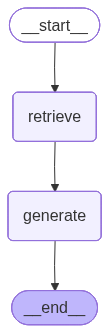

In [23]:
graph

In [24]:
from IPython.display import Markdown, display
response = graph.invoke({"question" : "What are the most common ways people use AI in their work?"})
display(Markdown(response["response"]))

Based on the figures in the study, the most common ways people use AI at work fall into four broad categories:

1. **Work‑related tasks** – using AI to help with professional duties (e.g., drafting or rewriting emails, preparing documents, or other office‑related work).  
2. **Asking for help** – querying the model for instructions, explanations, or troubleshooting (e.g., “User is asking for help fixing python databricks error”).  
3. **Doing tasks** – letting the model actually produce or complete work items (e.g., generating code, creating content, or performing data‑analysis steps).  
4. **Expressing** – using AI to communicate or share opinions (e.g., “User is complaining about grandmother” or other expressive interactions).  

These categories capture the most frequent ways people employ AI in their professional activities.

In [25]:
response = graph.invoke({"question" : "Do people use AI for their personal lives?"})
display(Markdown(response["response"]))

Yes. The study shows that people use ChatGPT for personal‑life tasks as well as work‑related ones. For example, the examples in the paper include:

- “User is rewriting an email to neighbors about plumbing to be more friendly” – a personal communication task.  
- “User is complaining about grandmother” – an expression of personal feelings or concerns.  

These illustrate that users turn to AI not only for professional work but also for everyday personal matters.

In [26]:
response = graph.invoke({"question" : "What concerns or challenges do people have when using AI?"})
display(Markdown(response["response"]))

I don't know.

In [27]:
response = graph.invoke({"question" : "Who is Batman?"})
display(Markdown(response["response"]))

I don't know.